# Chapter 5: Pretraining on Unlabeled Data

Reference: `LLMs-from-scratch/ch05/`

**Goals:**
- Download and prepare a text corpus
- Implement a training loop with cross-entropy loss
- Train the GPT model on your GPU
- Generate text with the trained model
- Save and load model checkpoints

In [1]:
import sys; sys.path.append('..')
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tiktoken
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.config import GPT_CONFIG_124M
from src.models import GPTModel, generate_text_simple
from src.dataloader import create_dataloader_v1


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Download & Prepare Dataset

In [5]:
with open("../data/the-verdict.txt", "r", encoding="utf-8") as f:
    text = f.read()
print(f"Loaded text: {len(text):,} characters")
print(f"First 200 chars:\n{text[:200]}")

Loaded text: 20,479 characters
First 200 chars:
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a


## 2. Training Loop

In [7]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen = 0
    global_step = -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
                    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f} | Val loss {val_loss:.3f}")

        # Text sample after each epoch
        model.eval()
        with torch.no_grad():
            context_ids = tokenizer.encode(start_context)
            context_tensor = torch.tensor(context_ids, device=device).unsqueeze(0)
            generated = generate_text_simple(model, context_tensor, max_new_tokens=50,
                                             context_size=GPT_CONFIG_124M["context_length"])
            print(f"\n{tokenizer.decode(generated[0].tolist())}\n")

    return train_losses, val_losses, track_tokens_seen

# Setup
GPT_CONFIG_124M["context_length"] = 256
torch.manual_seed(123)

tokenizer = tiktoken.get_encoding("gpt2")
split_idx = int(len(text) * 0.9)
train_loader = create_dataloader_v1(text[:split_idx], batch_size=8, max_length=256, stride=128)
val_loader   = create_dataloader_v1(text[split_idx:], batch_size=8, max_length=256, stride=128)

model = GPTModel(GPT_CONFIG_124M).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=10, eval_freq=5, eval_iter=1,
    start_context="I wondered", tokenizer=tokenizer)

Ep 1 (Step 000000): Train loss 9.764 | Val loss 9.843

I wondered the the the the the the the the the the the the the the the the the the the, the the, the the, the the the the, the the the the the the the the the the the, the the, the the, the

Ep 2 (Step 000005): Train loss 7.455 | Val loss 7.963

I wondered, the, the, the of the of the, the, the of the.


































Ep 3 (Step 000010): Train loss 5.976 | Val loss 6.759

I wondered had the of the of the of the of the of the of the of the of the of the of the, and, and, and of the of the of the of the of the of the of the of the of the of the of the

Ep 4 (Step 000015): Train loss 5.322 | Val loss 6.339

I wondered, and I was, and, I was, and, I was a, and, and, I was, and, and, and, and, I was, and, and, and, and, and, and, and, and I

Ep 5 (Step 000020): Train loss 4.676 | Val loss 6.247

I wondered had been his pictures, and, the picture--as, in the picture, and in the picture, as, and, and, as that, and I had 

## 3. Loss Tracking & Plotting

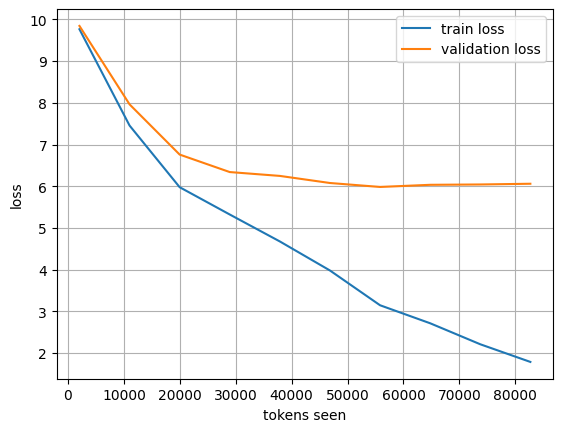

In [10]:
plt.Figure(figsize=(8,4))
plt.plot(tokens_seen,train_losses,label="train loss")
plt.plot(tokens_seen,val_losses,label="validation loss")
plt.xlabel("tokens seen")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

## 4. Text Generation

In [12]:
model.eval()
tokenizer=tiktoken.get_encoding("gpt2")

prompts=["I wondered", "The Picture", "Mrs.", "He said"]
for prompt in prompts:
    encoded=torch.tensor(tokenizer.encode(prompt),device=device).unsqueeze(0)
    with torch.no_grad():
        out=generate_text_simple(model,encoded,max_new_tokens=30,context_size=GPT_CONFIG_124M["context_length"])
        decoded=tokenizer.decode(out[0].tolist())
        print(f"Prompt:{prompt}")
        print(f"Output:{decoded}\n")

Prompt:I wondered
Output:I wondered if he had to work on--and by a tributes--and by the last word.









"

Prompt:The Picture
Output:The Picture a neutral surface to work on--as, so--his resolve being apparently irrevocable--the discussion gradually died out, and, as Mrs.

Prompt:Mrs.
Output:Mrs.
"Has he chucked his pictures too? I haven't seen a single one in the house."










Prompt:He said
Output:He said--as I had been the picture weekly--I had been the fact with the last word.









"



## 5. Save / Load Checkpoint

In [17]:
import os
os.makedirs("../checkpoints", exist_ok="True")

#Save
torch.save({"model_state_dict":model.state_dict(),
            "optimizer_state_dict":optimizer.state_dict(),
            "train_losses":train_losses,
            "val_losses":val_losses,
            "tokens_seen": tokens_seen},
            "../checkpoints/model_verdict.pth")
print("Checkpoint saved to checkpoints/model_verdict.pth")

checkpoint=torch.load("../checkpoints/model_verdict.pth",weights_only=False)
print(f"Loaded Checkpoint: trainloss={checkpoint['train_losses'][-1]:.3f},"
      f"val_loss={checkpoint['val_losses'][-1]:.3f}")


Checkpoint saved to checkpoints/model_verdict.pth
Loaded Checkpoint: trainloss=1.788,val_loss=6.059
